In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Vivek\Downloads\seaice.csv\seaice.csv")

# Overview

In [4]:
df.head()

,Year,Month,Day,Extent,Missing,Source Data,hemisphere
0,1978,10,26,10.231,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
1,1978,10,28,10.420,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
2,1978,10,30,10.557,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
3,1978,11,1,10.670,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
4,1978,11,3,10.777,0.0,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north


In [5]:
df.describe()

,Year,Month,Day,Extent,Missing
count,26354.000000,26354.000000,26354.000000,26354.000000,26354.000000
mean,2000.591941,6.507399,15.740685,11.494986,0.000003
std,10.896821,3.451938,8.801607,4.611734,0.000227
min,1978.000000,1.000000,1.000000,2.080000,0.000000
25%,1992.000000,4.000000,8.000000,7.601000,0.000000
50%,2001.000000,7.000000,16.000000,12.217000,0.000000
75%,2010.000000,10.000000,23.000000,15.114000,0.000000
max,2019.000000,12.000000,31.000000,20.201000,0.024000


In [6]:
df.describe(include="all")

,Year,Month,Day,Extent,Missing,Source Data,hemisphere
count,26354.000000,26354.000000,26354.000000,26354.000000,26354.000000,26354,26354
unique,NaN,NaN,NaN,NaN,NaN,26354,2
top,NaN,NaN,NaN,NaN,NaN,['ftp://sidads.colorado.edu/pub/DATASETS/nsid...,north
freq,NaN,NaN,NaN,NaN,NaN,1,13177
mean,2000.591941,6.507399,15.740685,11.494986,0.000003,NaN,NaN
std,10.896821,3.451938,8.801607,4.611734,0.000227,NaN,NaN
min,1978.000000,1.000000,1.000000,2.080000,0.000000,NaN,NaN
25%,1992.000000,4.000000,8.000000,7.601000,0.000000,NaN,NaN
50%,2001.000000,7.000000,16.000000,12.217000,0.000000,NaN,NaN
75%,2010.000000,10.000000,23.000000,15.114000,0.000000,NaN,NaN


In [7]:
for col in df.columns:
    print(f"{col}:{len(col)}")
    print()

Year:4

 Month:6

 Day:4

     Extent:11

    Missing:11

 Source Data:12

hemisphere:10



In [8]:
df.rename(columns={"     Extent":"Extent","    Missing":"Missing"," Source Data":"Source Data" },inplace=True)

In [40]:
df.rename(columns={" Month":"month"," Day":"day","Year":"year" },inplace=True)

In [9]:
df.drop(["Missing","Source Data"],axis=1, inplace=True)

In [10]:
df[df['hemisphere']=="north"].describe(include="all")

,Year,Month,Day,Extent,hemisphere
count,13177.000000,13177.000000,13177.000000,13177.000000,13177
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,north
freq,NaN,NaN,NaN,NaN,13177
mean,2000.591941,6.507399,15.740685,11.362796,NaN
std,10.897027,3.452003,8.801774,3.259783,NaN
min,1978.000000,1.000000,1.000000,3.340000,NaN
25%,1992.000000,4.000000,8.000000,8.670000,NaN
50%,2001.000000,7.000000,16.000000,12.076000,NaN
75%,2010.000000,10.000000,23.000000,14.236000,NaN


In [11]:
df[df['hemisphere']=="south"].describe(include="all")

,Year,Month,Day,Extent,hemisphere
count,13177.000000,13177.000000,13177.000000,13177.000000,13177
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,south
freq,NaN,NaN,NaN,NaN,13177
mean,2000.591941,6.507399,15.740685,11.627176,NaN
std,10.897027,3.452003,8.801774,5.645942,NaN
min,1978.000000,1.000000,1.000000,2.080000,NaN
25%,1992.000000,4.000000,8.000000,6.004000,NaN
50%,2001.000000,7.000000,16.000000,12.537000,NaN
75%,2010.000000,10.000000,23.000000,17.205000,NaN


# Distribution of Extent

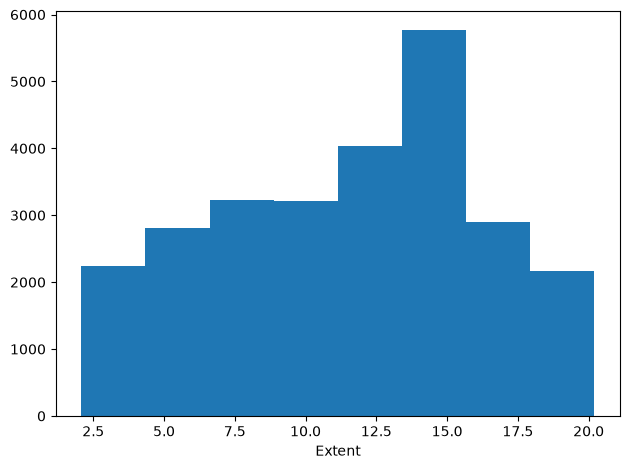

In [12]:
fig, ax = plt.subplots()
ax.hist(df['Extent'],bins =8)
ax.set_xlabel("Extent")
plt.tight_layout()

## Insights
##### Left-skewed

# Year wise average extent of ice

In [13]:
df.columns

Index(['Year', ' Month', ' Day', 'Extent', 'hemisphere'], dtype='str')

In [14]:
yearwise_extent = df.groupby(['Year','hemisphere'])['Extent'].mean()
yearwise_extent

Year  hemisphere
1978  north         12.487000
      south         13.466676
1979  north         12.319560
      south         11.719137
1980  north         12.334148
                      ...    
2017  south         10.748926
2018  north         10.326964
      south         10.937660
2019  north         13.610510
      south          4.876781
Name: Extent, Length: 84, dtype: float64

In [15]:
yearwise_extent_unstack = yearwise_extent.unstack(level = -1)


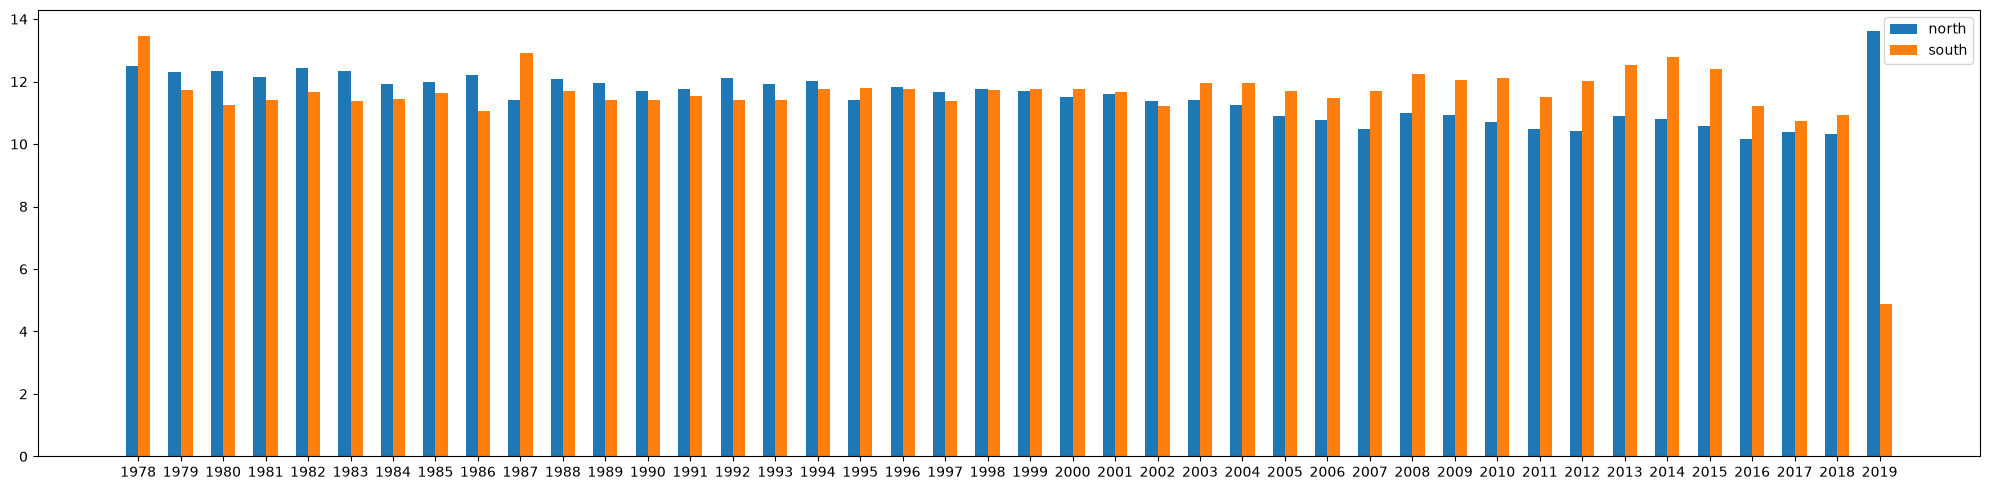

In [16]:
fig, ax = plt.subplots(figsize = (20,5))
ax.grouped_bar(yearwise_extent_unstack.values, tick_labels = yearwise_extent_unstack.index, labels = yearwise_extent_unstack.columns)
ax.legend()
plt.tight_layout()

In [41]:
df.columns

Index(['year', 'month', 'day', 'Extent', 'hemisphere'], dtype='str')

In [33]:
df[(df['Year'] == 2019) & (df['hemisphere'] == 'south')]['Extent'].to_numpy()

array([ 5.201,  5.035,  4.889,  4.784,  4.654,  4.591,  4.511,  4.392,
        4.287,  4.149,  4.014,  4.02 ,  3.913,  3.801,  3.752,  3.74 ,
        3.716,  3.599,  3.545,  3.462,  3.375,  3.344,  3.3  ,  3.266,
        3.178,  3.133,  3.127,  3.064,  3.007,  2.984,  2.938,  2.932,
        2.952,  2.928,  2.89 ,  2.851,  2.852,  2.815,  2.816,  2.785,
        2.78 ,  2.739,  2.661,  2.623,  2.597,  2.58 ,  2.558,  2.544,
        2.588,  2.567,  2.536,  2.519,  2.462,  2.463,  2.476,  2.464,
        2.487,  2.465,  2.444,  2.474,  2.531,  2.544,  2.555,  2.562,
        2.597,  2.619,  2.643,  2.743,  2.779,  2.776,  2.842,  2.917,
        3.012,  2.957,  3.007,  3.081,  3.171,  3.291,  3.332,  3.42 ,
        3.504,  3.618,  3.638,  3.685,  3.82 ,  3.868,  3.92 ,  3.975,
        4.045,  4.163,  4.24 ,  4.417,  4.478,  4.564,  4.73 ,  4.856,
        4.902,  4.993,  5.103,  5.207,  5.304,  5.395,  5.513,  5.594,
        5.719,  5.919,  6.023,  6.042,  6.091,  6.193,  6.247,  6.255,
      

## Insights
##### North region ice is decreasing, but in 2019 it highest (though data is of 5 months only)
##### South region ice is volatile, less than north till 1998, then more than north, but in 2019 it's average is approx 4 (5 months data)

# Year and month wise average

In [47]:
df.shape[0]

26354

In [49]:
df.iloc[0,:]

year            1978
month             10
day               26
Extent        10.231
hemisphere     north
Name: 0, dtype: object

In [48]:
df.iloc[(df.shape[0]) -1,:]

year            2019
month              5
day               31
Extent        10.436
hemisphere     south
Name: 26353, dtype: object

In [44]:
yearmonthwise_extent = df.groupby(['year','month'])['Extent'].mean()
yearmonthwise_extent

year  month
1978  10       14.050833
      11       13.770767
      12       12.031156
1979  1        10.408100
      2         9.658179
                 ...    
2019  1         8.693500
      2         8.527286
      3         8.858065
      4         9.581617
      5        10.499339
Name: Extent, Length: 488, dtype: float64

<BarContainer object of 488 artists>

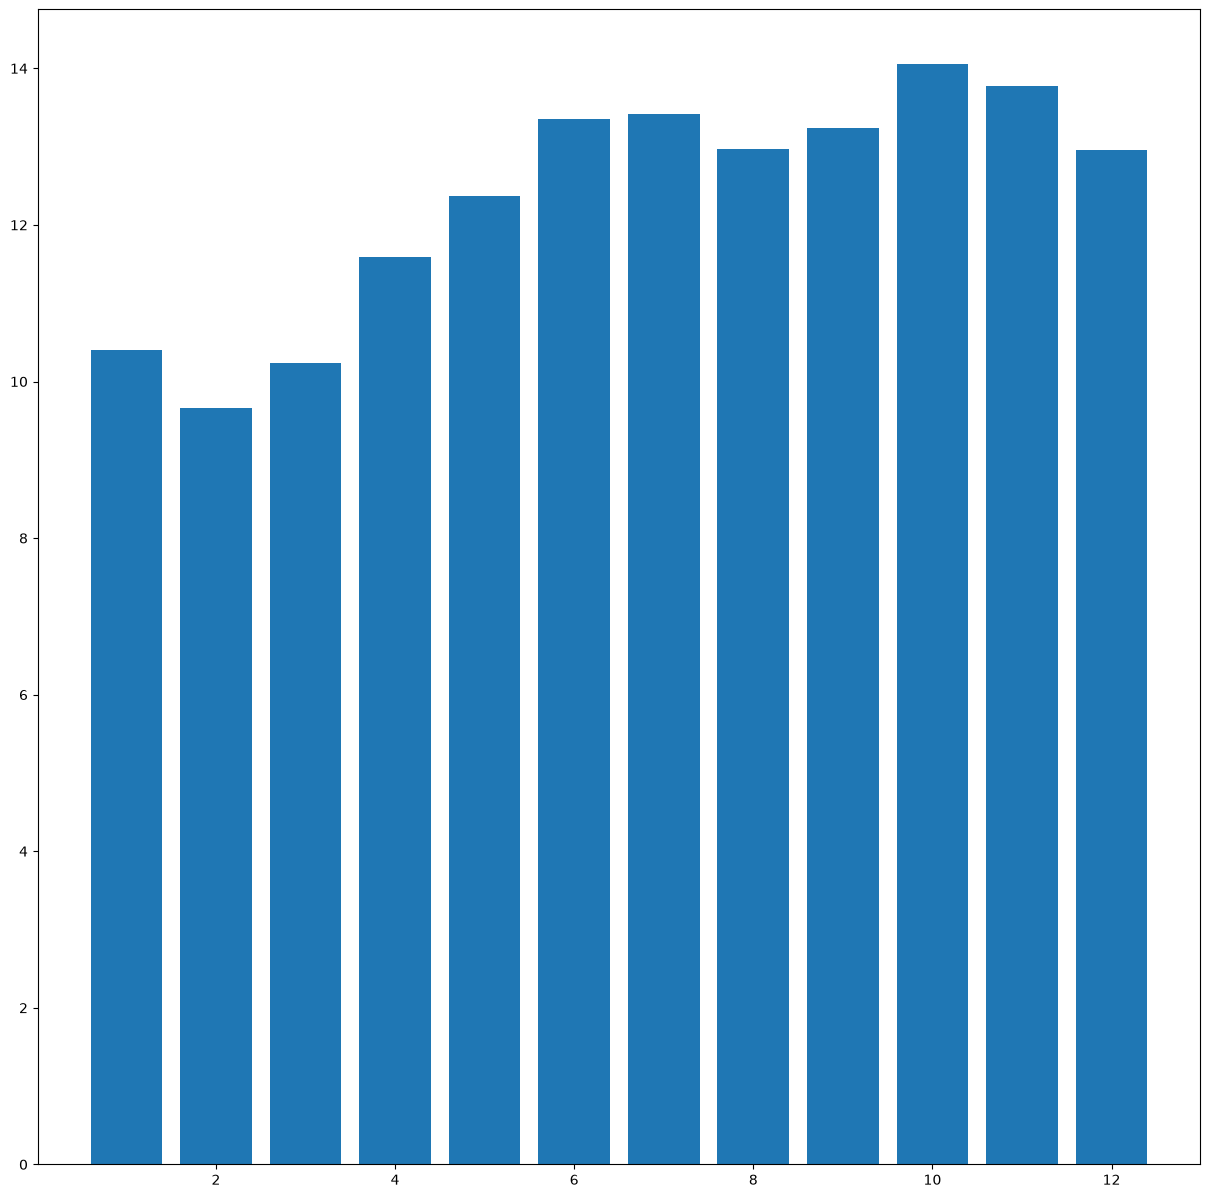

In [55]:
fig, ax = plt.subplots(figsize = (15,15))
ax.bar(yearmonthwise_extent.index.get_level_values(1),yearmonthwise_extent)

## Insgiths
##### more ice during winter season and less in others

# Year to Year increase or decrease

In [65]:
yearwise_extent_unstack.head()

hemisphere,north,south
Year,,
1978,12.487000,13.466676
1979,12.319560,11.719137
1980,12.334148,11.236290
1981,12.135486,11.416809
1982,12.439445,11.658066


In [75]:
yearwise_extent_unstack.shape[0]

42

In [68]:
yearwise_extent_unstack.columns

Index(['north', 'south'], dtype='str', name='hemisphere')

In [73]:
#pd.concat([yearwise_extent_unstack, yearwise_extent_unstack],axis = 1, join="inner")

In [88]:
yearwise_extent_unstack.iloc[0]

hemisphere
north    12.487000
south    13.466676
Name: 1978, dtype: float64

In [87]:
yearwise_extent_unstack.loc[1978,'north']

np.float64(12.487)

In [85]:
yearwise_extent_unstack.iloc[0,0]

np.float64(12.487)

In [93]:
array1 = []
array2 = []
columns = ['north', 'south']

for j in range(1,42):
    diff = (yearwise_extent_unstack.iloc[j,0]) - (yearwise_extent_unstack.iloc[j - 1,0])
    # print(f"{yearwise_extent_unstack.iloc[j,i]}:{diff}" )
    array1.append(diff)

for j in range(1,42):
    diff = (yearwise_extent_unstack.iloc[j,1]) - (yearwise_extent_unstack.iloc[j - 1,1])
    # print(f"{yearwise_extent_unstack.iloc[j,i]}:{diff}" )
    array2.append(diff)


In [102]:
np.array(array1)

array([-0.16743956,  0.0145871 , -0.1986612 ,  0.30395872, -0.10354888,
       -0.42329508,  0.07399781,  0.22162514, -0.81099677,  0.69594222,
       -0.1263147 , -0.2730137 ,  0.05541644,  0.36122334, -0.18742882,
        0.08826575, -0.59620822,  0.4256773 , -0.17317319,  0.08976712,
       -0.06591507, -0.18329089,  0.09184157, -0.23715068,  0.03435616,
       -0.15678749, -0.33345908, -0.13436164, -0.29851781,  0.5037511 ,
       -0.04587713, -0.22057808, -0.22789589, -0.07739753,  0.49101671,
       -0.10661918, -0.22467945, -0.4023383 ,  0.22922323, -0.06573699,
        3.28354555])

In [104]:
dict_diff = {
    "north" : pd.Series(array1),
    "south" : pd.Series(array2)
} 
df_diff = pd.DataFrame(dict_diff)
df_diff.head()

,north,south
0,-0.167440,-1.747539
1,0.014587,-0.482848
2,-0.198661,0.180519
3,0.303959,0.241257
4,-0.103549,-0.288153


In [117]:
yearwise_extent_unstack.index[1:]

Index([1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019],
      dtype='int64', name='Year')

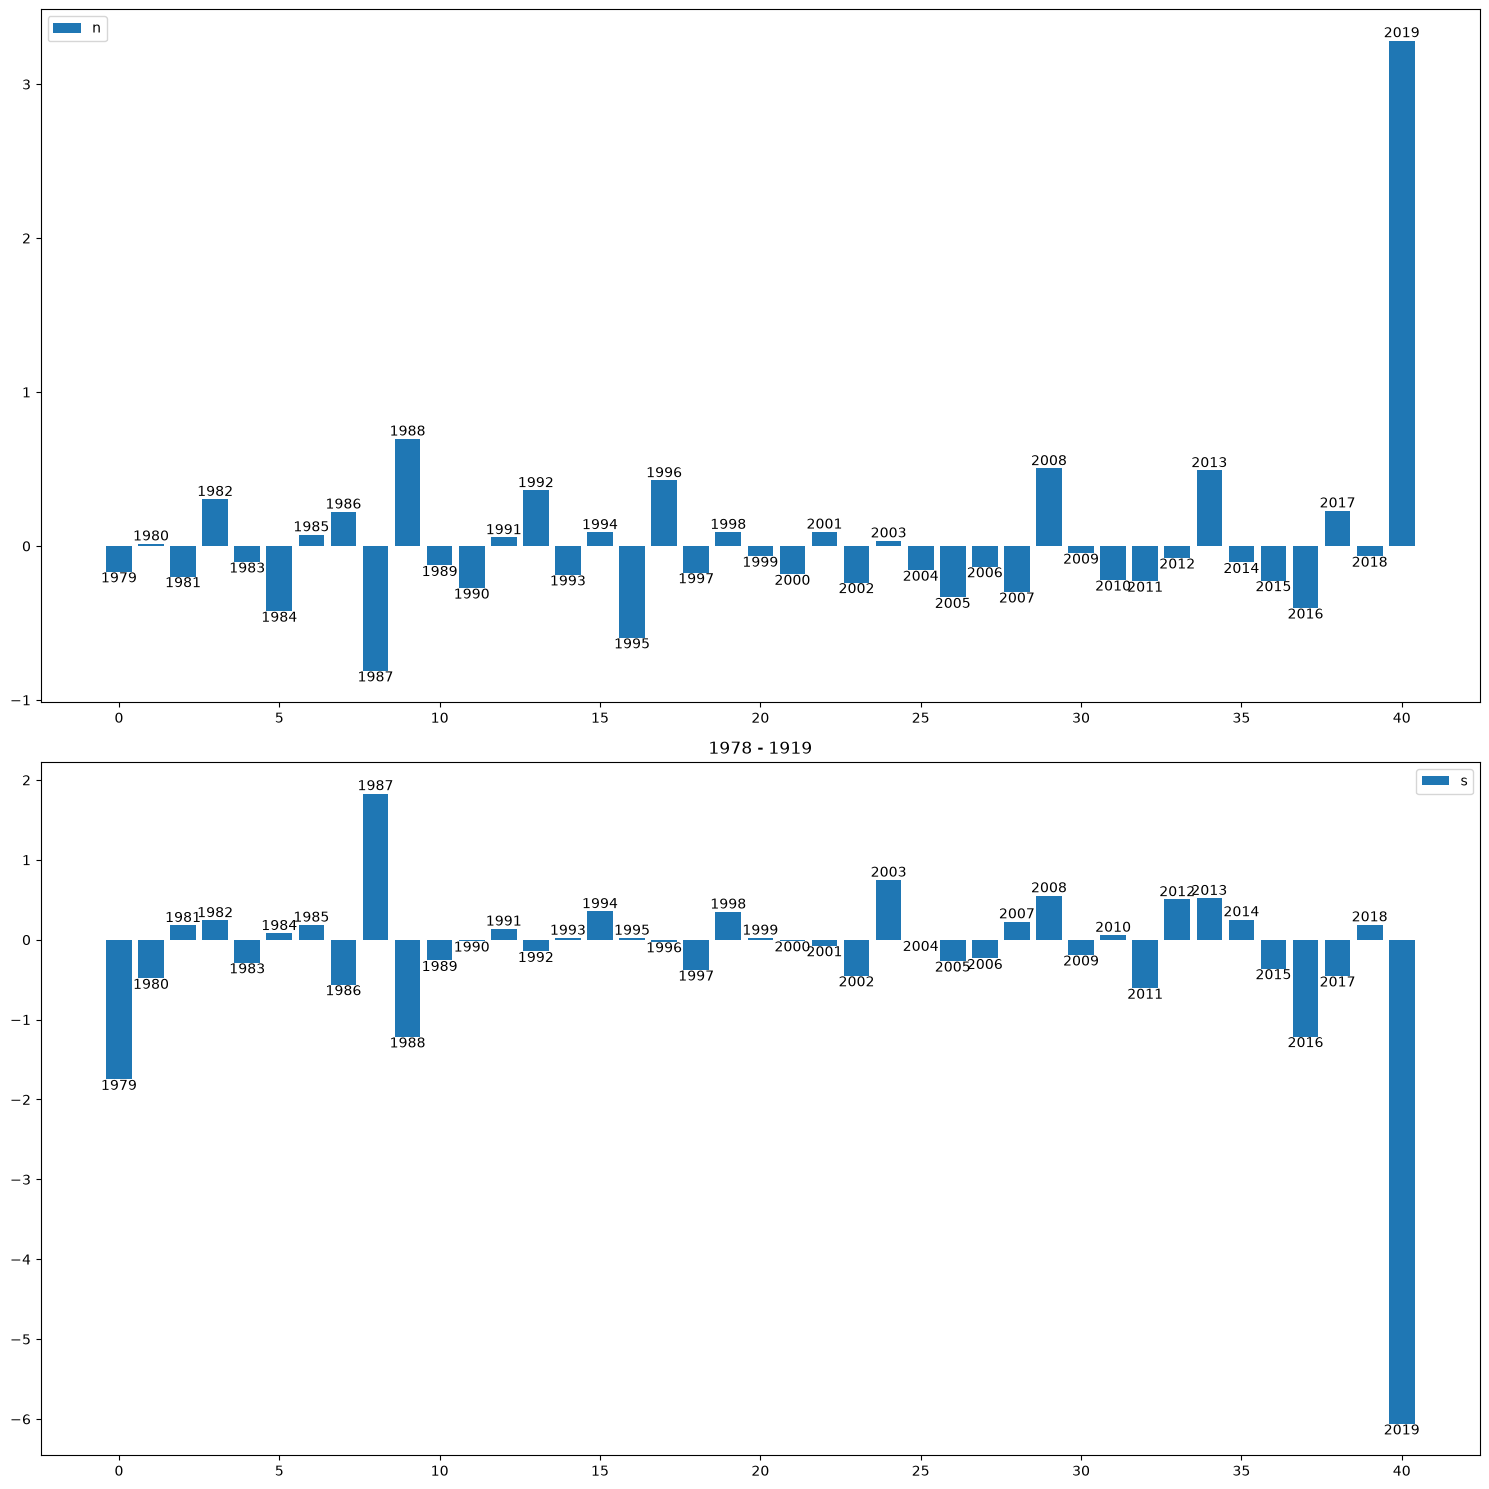

In [120]:
fig, ax = plt.subplots(2,1,figsize = (15,15))
barn = ax[0].bar(df_diff.index, height = df_diff['north'])
ax[0].legend("north")
ax[0].bar_label(barn,yearwise_extent_unstack.index[1:])

bars = ax[1].bar(df_diff.index, height = df_diff['south'])
ax[1].legend("south")
ax[1].bar_label(bars,yearwise_extent_unstack.index[1:])
plt.title(label="1978 - 1919")
plt.tight_layout()
